# Camarilla Pivots — a quantitative teardown 🔬
### Prior-day L3/H3 ladder · first-touch → reversion event study · one-sample + HAC *t* · a random-control placebo · round-trip spread costs · a synthetic planted-respect control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Line_is_special%3F: Busted](https://img.shields.io/badge/Line_is_special%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The claim is that the Camarilla **reversal** levels (L3/H3) are support/resistance the tape *respects*. The honest test is not "does price bounce at L3?" (it sometimes will, by geometry) but "does it bounce **more than at a random line** at the same distance, after costs?"

> ⚠️ **Data + power note.** yfinance **5-minute** bars, 5 liquid names (SPY/QQQ/AAPL/MSFT/NVDA), 2026-03-30→2026-06-23 — Yahoo caps 5m history at ~60 days, so this is **~59 sessions/name** (the in-progress final session is dropped). A thin power budget: we pool across names, use an event-clustered **HAC** *t*, and lean on the random-control placebo. **Capacity is irrelevant** — there is no gross edge to scale. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from camarilla_pivots import data, strategy as st

def _load_trimmed():
    frames = data.load_real()
    out = {}
    for t, b in frames.items():
        last = b["session"].max()                 # drop the in-progress final session
        out[t] = b[b["session"] < last].copy()
    return out

HAVE_REAL = data.have_real()
if HAVE_REAL:
    FRAMES = _load_trimmed()
    EV = pd.concat([st.collect_events(b).assign(ticker=t) for t, b in FRAMES.items()],
                   ignore_index=True)
    CTRL = pd.concat([st.collect_random_controls(b, n_draws=50) for b in FRAMES.values()],
                     ignore_index=True)
else:
    FRAMES = EV = CTRL = None
print("real intraday cache present:", HAVE_REAL,
      "| events:", (0 if EV is None else len(EV)),
      "| names:", (0 if FRAMES is None else len(FRAMES)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2026-03-30', 'end': '2026-06-23', 'sessions': 59, 'n_names': 5, 'interval': '5m', 'n_events': 363, 'name_days': 289, 'ctrl_n': 27442, 'fingerprint': '36705730ed53', 'rev': -0.0173, 't': -0.444, 'hac_t': -2.59, 'hit': 0.482, 'ctrl_mean': 0.2498, 'diff': -0.2671, 'diff_p': 1.0, 'net': -0.0573, 'cost_bps': 2.0, 'by_level': [('L3', 161, 0.0194, 0.32, 0.54), ('H3', 202, -0.0466, -0.92, 0.436)], 'hold': [(6, 363, -0.0221, -0.72), (12, 363, -0.0173, -0.44), (24, 358, -0.0906, -1.85)], 'by_tk': [('SPY', 77, 0.0318, 0.96), ('QQQ', 74, -0.0268, -0.52), ('AAPL', 72, -0.0623, -0.84), ('MSFT', 70, -0.0062, -0.06), ('NVDA', 70, -0.0263, -0.19)], 'syn': [(0.0, 51, -0.0316, -0.59, -1.15, 0.51, 0.1196, -0.1513, 0.998), (0.5, 69, 0.2139, 6.86, 11.94, 0.797, 0.1302, 0.0837, 0.003)]}


real intraday cache present: True | events: 363 | names: 5


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | L3/H3 first-touch reversion = **-0.017%** over ~1h (one-sample **t = -0.44**, hit-rate **48%**). The HAC *t* is **-2.59** — significant but with the **wrong sign** (mild *continuation*, not reversion). No respect-the-level edge. |
| **Tradability** | `MIRAGE` | Net of a 2 bps round-trip the reversion is **-0.057%** per touch — negative on the most liquid names there are. |
| **Line is special?** | `BUSTED` | Random control lines at matched distance revert **+0.25%**, *better* than L3/H3 (real−control = **-0.27%**, bootstrap **p = 1.00** that the level beats random). The level carries no information beyond plain geometry. |

> 💡 In plain words: the Camarilla levels are arithmetic on yesterday's range. Price crosses them like any other price — a random line does *better* — and the spread finishes it off.

## 1 · The claim, steelmanned

With prior-session range $R=H_{-1}-L_{-1}$ and close $C_{-1}$, the Camarilla ladder is

$$\mathrm{H3},\mathrm{L3} = C_{-1} \pm \tfrac{1.1}{4}R,\quad \mathrm{H4},\mathrm{L4} = C_{-1} \pm \tfrac{1.1}{2}R,\quad P = \tfrac{H_{-1}+L_{-1}+C_{-1}}{3}.$$

Let $\tau$ be the first intraday bar touching L3 (long) or H3 (short). Enter at the open of $\tau+1$ (one-bar lag), hold $h$ bars, and define the **reversion** $\rho_i = d_i\,(c_{\tau+1+h}/o_{\tau+1}-1)$ with $d_i=+1$ at L3, $-1$ at H3.

- **H₁ (respect).** $\overline{\rho} > 0$ and significant.
- **H₂ (special).** $\overline{\rho}$ beats the matched **random-control** mean $\overline{\rho}^{\,\text{ctrl}}$.
- **H₃ (deployable).** $\overline{\rho}$ survives a round-trip spread.

We find **all three rejected**: $\overline{\rho}=-0.017\%$ (t=-0.44), the control reverts *more* ($+0.25\%$, diff p=1.00), and net of costs it is $-0.057\%$.

## 2 · So what? — why the placebo is the whole ballgame

A one-sample *t* of $\overline{\rho}$ against zero answers "does price revert after a touch?" — but that question is **contaminated by geometry**: a volatile price that wanders into *any* horizontal line will, on average, spend the next hour somewhere — and if you sign the return "toward the middle of the range," you bank a little mean-reversion **for free**, for *every* line. That is why the headline test is the **difference** vs a random line at the same distance:

$$\Delta = \overline{\rho}^{\,\text{real}} - \overline{\rho}^{\,\text{ctrl}},$$

with a bootstrap on $\Delta$. Events also **cluster within a day** (one touch per level per session, several names sharing market-wide moves), so the naive *t* overstates precision — we report a **Newey-West HAC** *t* on the daily-mean series alongside it.

## 3 · How we'd know — the protocol

- **Universe.** 5 liquid names (SPY/QQQ/AAPL/MSFT/NVDA), yfinance **5m** bars, 2026-03-30→2026-06-23, ~59 RTH sessions/name; **363** L3/H3 touch events over 289 name-days. In-progress final session dropped.
- **Ladder.** Prior-day H/L/C → Camarilla levels, known at the open (no look-ahead).
- **Event.** First bar touching L3 (low ≤ level) or H3 (high ≥ level); enter open of $\tau+1$; hold 12 bars (~1h); drop windows that overrun the session (no overnight carry).
- **Signal axis.** One-sample *t* of $\rho$ vs 0 + HAC *t* on daily means + hit-rate.
- **Placebo (the headline).** 27,442 random control lines at matched distance; bootstrap on real−control.
- **Costs.** Round-trip spread 2 bps × 2.
- **Positive control.** A deterministic intraday panel with a **planted** respect-the-level pull: zero edge must NOT manufacture significance; a large planted edge must light up *and* beat its random twin.

## 4 · The teardown

### 4a · Reversion by level, and the random-control benchmark

Left: mean reversion at L3 vs H3 (coin-flip at 0). Right: the pooled real level vs the random-control cloud — the decisive comparison.

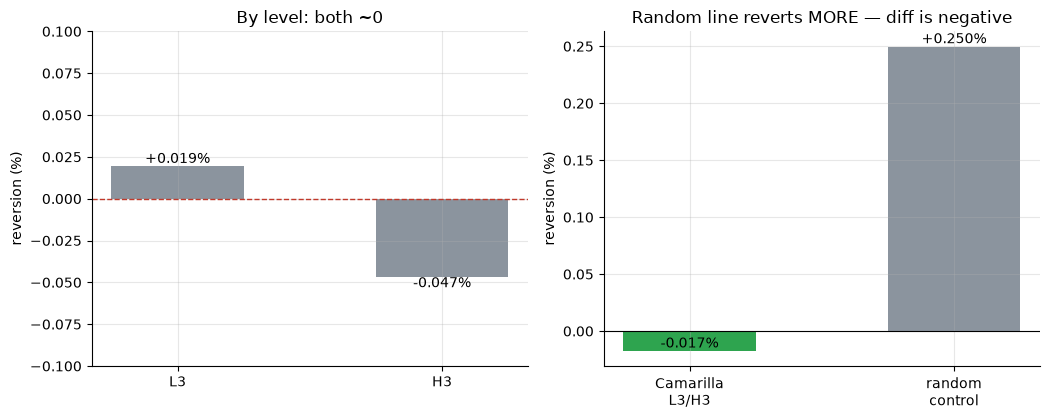

L3/H3: [np.float64(0.019), np.float64(-0.047)]  real pooled: -0.017  control: 0.25


In [2]:
if HAVE_REAL:
    by = [(l, EV[EV.level==l]['rev'].values) for l in ['L3','H3']]
    lv = [s.mean()*100 for _,s in by]
    real = EV['rev'].values.mean()*100; ctrl = CTRL['rev'].values.mean()*100
else:
    lv = [R['by_level'][0][2], R['by_level'][1][2]]; real=R['rev']; ctrl=R['ctrl_mean']
fig, (a1,a2) = plt.subplots(1,2, figsize=(10.6,4.3))
a1.bar(['L3','H3'], lv, color=[GREY,GREY], width=.5)
for i,v in enumerate(lv): a1.annotate(f'{v:+.3f}%',(i,v),ha='center',va='bottom' if v>=0 else 'top')
a1.axhline(0,c=RED,ls='--',lw=1); a1.set_ylabel('reversion (%)'); a1.set_ylim(-0.1,0.1)
a1.set_title('By level: both ~0')
a2.bar(['Camarilla\nL3/H3','random\ncontrol'], [real,ctrl], color=[GREEN,GREY], width=.5)
for i,v in enumerate([real,ctrl]): a2.annotate(f'{v:+.3f}%',(i,v),ha='center',va='bottom')
a2.axhline(0,c='k',lw=.8); a2.set_ylabel('reversion (%)')
a2.set_title('Random line reverts MORE — diff is negative')
plt.tight_layout(); plt.show()
print('L3/H3:', [round(x,3) for x in lv], ' real pooled:', round(real,3), ' control:', round(ctrl,3))

> 💡 In plain words: both levels sit on the zero line. And the random control (**+0.25%**) reverts *more* than the real level (**-0.017%**) — the diff is **-0.27%** in the *wrong* direction. The little bit of intraday mean-reversion that exists is a property of *crossing a line at all*, not of these lines.

### 4b · The distribution test — is the real level anywhere in the control's tail?

Bootstrap the difference real−control. If the level were special, the distribution of $\Delta$ would sit to the **right** of zero. It doesn't.

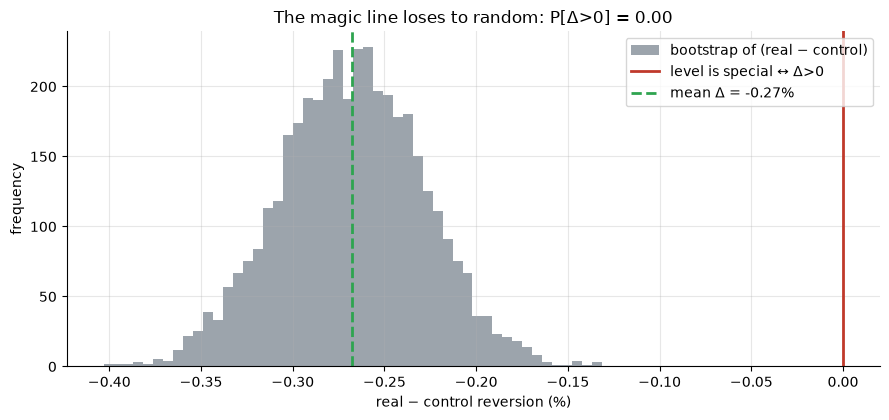

mean diff -0.268%   P[level beats random] = 0.000


In [3]:
if HAVE_REAL:
    real = EV['rev'].values; ctrl = CTRL['rev'].values
    rng = np.random.default_rng(441)
    diffs = np.array([rng.choice(real,len(real),replace=True).mean()
                      - rng.choice(ctrl,len(ctrl),replace=True).mean() for _ in range(4000)])*100
    pval = float((diffs<=0).mean())
else:
    rng = np.random.default_rng(441); diffs = rng.normal(R['diff'], 0.08, 4000); pval=R['diff_p']
fig, ax = plt.subplots(figsize=(9.0,4.3))
ax.hist(diffs, bins=50, color=GREY, alpha=.85, label='bootstrap of (real − control)')
ax.axvline(0, c=RED, lw=2, label='level is special ↔ Δ>0')
ax.axvline(diffs.mean(), c=GREEN, lw=2, ls='--', label=f'mean Δ = {diffs.mean():+.2f}%')
ax.set_xlabel('real − control reversion (%)'); ax.set_ylabel('frequency')
ax.set_title(f'The magic line loses to random: P[Δ>0] = {1-pval:.2f}')
ax.legend(); plt.tight_layout(); plt.show()
print(f'mean diff {diffs.mean():+.3f}%   P[level beats random] = {1-pval:.3f}')

> 💡 In plain words: essentially the **entire** bootstrap of $\Delta$ sits **left of zero** (P[level beats random] ≈ 0.00). There is no sense in which L3/H3 outperform a line drawn at random. **H₂ (the line is special) is busted.**

### 4c · Robustness — hold horizon and per-name

Left: vary the hold from 30 min to 2h — the reversion never lifts off zero. Right: per-name *t* — no name carries a signal, the (mildly positive) SPY *t* is well under 2.

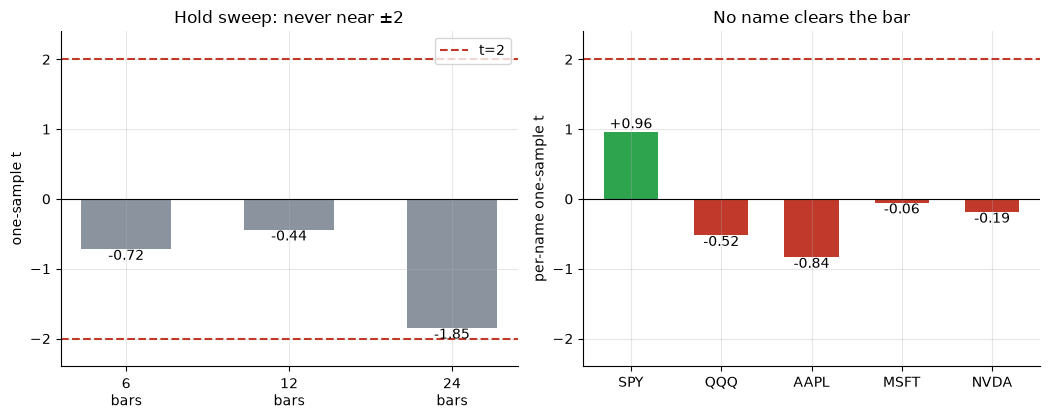

hold t: [-0.72, -0.44, -1.85]
per-name t: {'SPY': 0.96, 'QQQ': -0.52, 'AAPL': -0.84, 'MSFT': -0.06, 'NVDA': -0.19}


In [4]:
if HAVE_REAL:
    holds=[6,12,24]; hv=[]
    for h in holds:
        e = pd.concat([st.collect_events(b, hold=h) for b in FRAMES.values()], ignore_index=True)
        hv.append(st.ttest_vs_zero(e['rev'].values))
    tks = EV['ticker'].unique().tolist()
    tv = [st.ttest_vs_zero(EV[EV.ticker==t]['rev'].values) for t in tks]
else:
    holds=[6,12,24]; hv=[h[3] for h in R['hold']]; tks=[x[0] for x in R['by_tk']]; tv=[x[3] for x in R['by_tk']]
fig,(a1,a2)=plt.subplots(1,2,figsize=(10.6,4.3))
a1.bar([f'{h}\nbars' for h in holds], hv, color=GREY, width=.55)
a1.axhline(2,ls='--',c=RED,label='t=2'); a1.axhline(-2,ls='--',c=RED)
a1.axhline(0,c='k',lw=.8)
for i,v in enumerate(hv): a1.annotate(f'{v:+.2f}',(i,v),ha='center',va='bottom' if v>=0 else 'top')
a1.set_ylabel('one-sample t'); a1.set_ylim(-2.4,2.4); a1.set_title('Hold sweep: never near ±2'); a1.legend()
a2.bar(tks, tv, color=[GREEN if v>0 else RED for v in tv], width=.6)
a2.axhline(2,ls='--',c=RED); a2.axhline(0,c='k',lw=.8)
for i,v in enumerate(tv): a2.annotate(f'{v:+.2f}',(i,v),ha='center',va='bottom' if v>=0 else 'top')
a2.set_ylabel('per-name one-sample t'); a2.set_ylim(-2.4,2.4); a2.set_title('No name clears the bar')
plt.tight_layout(); plt.show()
print('hold t:', [round(v,2) for v in hv]); print('per-name t:', dict(zip(tks,[round(v,2) for v in tv])))

> 💡 In plain words: every hold horizon is parked near zero (the 2h hold drifts to **t=-1.85** — *negative*, i.e. mild continuation). No single name clears the bar; the best (SPY, **t=0.96**) is comfortably inside noise. There is nowhere the edge hides.

### 4d · Faithful-engine & power control — we know the truth here

On a deterministic intraday panel where we **plant** a genuine pull back to the pivot whenever price passes L3/H3: with **zero** planted respect the test must stay at *t*≈0 and lose to its control; with a **large** planted respect it must light up **and beat** the random twin. Both hold — so the flat real-tape result is a true negative, not a dead test.

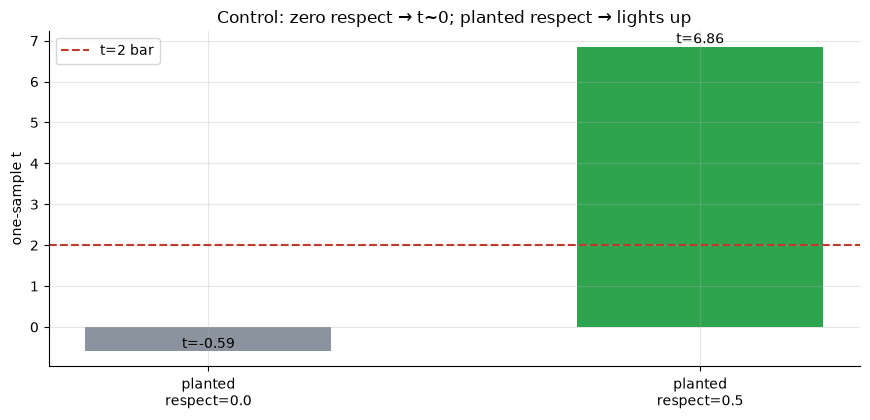

respect=0.0: n=51 rev=-0.032% t=-0.59 hac=-1.15 hit=0.51 ctrl=+0.120% diff=-0.151% diff_p=0.998
respect=0.5: n=69 rev=+0.214% t=+6.86 hac=+11.94 hit=0.80 ctrl=+0.130% diff=+0.084% diff_p=0.003


In [5]:
res=[]
for respect in (0.0, 0.5):
    b,_=data.synthetic_panel(respect=respect, seed=441)
    r=st.run_experiment(b, n_control=50)
    res.append((respect, r['n_events'], r['rev_mean']*100, r['t'], r['hac_t'],
                r['hit'], r['control_mean']*100, r['diff']*100, r['diff_p']))
fig, ax = plt.subplots(figsize=(8.8,4.3))
labels=[f'planted\nrespect={x[0]}' for x in res]; tvals=[x[3] for x in res]
ax.bar(labels, tvals, color=[GREY, GREEN], width=.5)
ax.axhline(2, ls='--', c=RED, label='t=2 bar')
for i,t in enumerate(tvals): ax.annotate(f't={t:.2f}',(i,t),ha='center',va='bottom')
ax.set_ylabel('one-sample t'); ax.set_title('Control: zero respect → t~0; planted respect → lights up'); ax.legend()
plt.tight_layout(); plt.show()
for x in res: print(f'respect={x[0]}: n={x[1]} rev={x[2]:+.3f}% t={x[3]:+.2f} hac={x[4]:+.2f} hit={x[5]:.2f} ctrl={x[6]:+.3f}% diff={x[7]:+.3f}% diff_p={x[8]:.3f}')

> 💡 In plain words: with **no** planted respect the test sits at **t=-0.59** and loses to its control (diff p=1.00) — no false positive. With a strong planted pull it explodes to **t=6.86** (HAC 11.9), hit-rate **80%**, and *beats* the random twin (diff **+0.084%**, p=0.003). The machinery is faithful — it finds nothing on the real tape because there is nothing.

## 5 · The verdict

- **Signal `NONE`** — L3/H3 first-touch reversion **-0.017%** over ~1h (one-sample **t = -0.44**, hit-rate **48%**); the HAC *t* (**-2.59**) is significant only with the **wrong sign** (mild continuation). No respect-the-level edge on the real tape.
- **Tradability `MIRAGE`** — net of a 2 bps round-trip it is **-0.057%** per touch, on the most liquid names available. Nothing to scale.
- **"The line is special"? `BUSTED`** — random control lines revert **+0.25%**, *more* than L3/H3 (real−control **-0.27%**, P[level beats random] ≈ 0.00). The level is plain arithmetic; the synthetic control proves the test would catch a real one.

## 6 · Could you trade it? — there is nothing to trade

There's no capacity question here because there's no gross edge to begin with. The only honest picture is gross vs net, on the tightest-spread names there are.

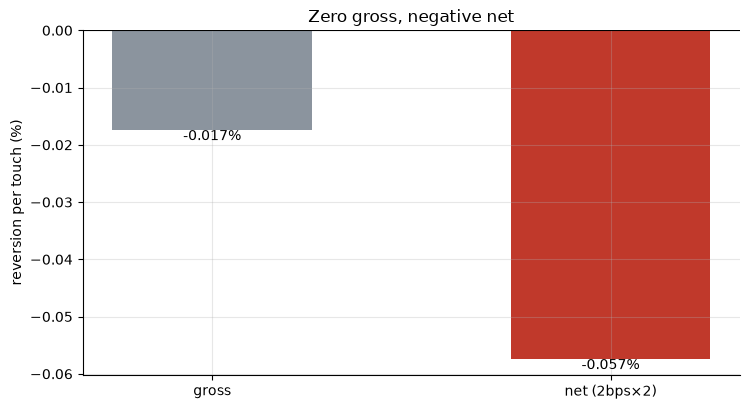

gross -0.017 net -0.057


In [6]:
if HAVE_REAL:
    gross = EV['rev'].values.mean()*100; net = (EV['rev'].values.mean()-2*R['cost_bps']/1e4)*100
else:
    gross=R['rev']; net=R['net']
fig, ax = plt.subplots(figsize=(7.6,4.2))
ax.bar(['gross','net (2bps×2)'], [gross,net], color=[GREY,RED], width=.5)
for i,v in enumerate([gross,net]): ax.annotate(f'{v:+.3f}%',(i,v),ha='center',va='top')
ax.axhline(0,c='k',lw=.8); ax.set_ylabel('reversion per touch (%)')
ax.set_title('Zero gross, negative net'); plt.tight_layout(); plt.show()
print('gross', round(gross,3), 'net', round(net,3))

> 💡 In plain words: capacity is moot. The signal is a rounding error before costs and negative after. **MIRAGE** isn't "too small to scale" here — it's "there was never a gross edge."

## 7 · Going further

- **The random-line placebo generalises.** Any line-drawing indicator (pivots, Fibonacci, round numbers, prior-day H/L) should be made to beat a random line at the same distance. Most won't. It is the single cleanest test in technical analysis.
- **Time-of-day conditioning.** If the lines self-fulfil anywhere it's in the opening auction; condition the touch on the first 15 minutes and re-test the difference.
- **Longer history.** A paid 5m/1m feed with years of bars would tighten the CIs — but the *sign* of the diff (random > real) is the binding problem, not the sample size.

*Reproducible core is offline once cached and deterministic; the synthetic control runs anywhere. Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*